# 10. Price prediction backtesting

Plug the RF model from notebook 08 into CSP entry decisions. Run a simple week-independent backtest on the test window (2025-06-02 → 2026-03-30) and compare five strategies:

- **S0 baseline**: always sell CSP at 1% yield target (rule only, no model)
- **S1 `p_filled < 0.30`**: only enter if model's P(filled) is below 30%
- **S2 bottom-quintile**: each Monday, take only the bottom 20% by P(filled) across HQ tickers
- **S3 edge > 0.05**: enter only when `p_mkt_filled - p_ml_filled > 0.05` (market overestimates fill; model says "safer than market thinks")
- **S4 EV > 0**: enter only when `premium - p_ml * expected_loss > 0`

**Setup**: for each CSP candidate in `strategy_labels` at `yield_target = 0.01`, join the 23 price features from `price_features.parquet`, snap the actual moneyness to the nearest OTM bin in `[1%, 2%, 3%, 4%, 5%]`, and query the model.

**Notes on this backtest**:
- Week-independent trades (no wheel / no CC re-selling on assignment). The point is to isolate the value of the entry filter. Wheel dynamics were evaluated separately in notebook 06.
- Portfolio weekly return = mean of per-ticker `pnl_pct_capital` across 35 tickers (with idle returning 0 on skipped weeks).
- Already-computed `pnl_pct_capital` from `strategy_labels` includes bid-fill premium minus intrinsic loss if assigned. Fees are included from notebook 03.

In [1]:
import math
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


FEATURES_PATH = Path("output/07_price_prediction_feature_engineering/price_features.parquet")
LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
MODEL_PATH = Path("output/08_price_prediction_modeling/price_model.pkl")
OUT_DIR = Path("output/10_price_prediction_backtesting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YIELD_TARGET = 0.01
OTM_BINS = [0.01, 0.02, 0.03, 0.04, 0.05]
TEST_START = pd.Timestamp("2025-06-02")

## Load + assemble model inputs

In [2]:
labels = pd.read_parquet(LABELS_PATH)
labels["monday_date"] = pd.to_datetime(labels["monday_date"])
features = pd.read_parquet(FEATURES_PATH)
features["monday_date"] = pd.to_datetime(features["monday_date"])
bundle = joblib.load(MODEL_PATH)
model = bundle["model"]
FEATURE_NAMES = bundle["feature_names"]

csp_trades = labels[
    (labels["type"] == "CSP")
    & (labels["yield_target"] == YIELD_TARGET)
    & (labels["monday_date"] >= TEST_START)
].copy()

feature_cols = [f for f in FEATURE_NAMES if f not in ("otm_pct", "type_cc")]
csp = csp_trades.merge(
    features[["ticker", "monday_date"] + feature_cols],
    on=["ticker", "monday_date"],
    how="left",
)
csp = csp.dropna(subset=feature_cols).copy().reset_index(drop=True)


def nearest_otm(moneyness):
    return OTM_BINS[np.argmin([abs(moneyness - b) for b in OTM_BINS])]


csp["otm_snapped"] = csp["moneyness_actual"].apply(nearest_otm)
csp["type_cc"] = 0  # CSP

X = csp[feature_cols + ["otm_snapped"]].copy()
X.columns = feature_cols + ["otm_pct"]
X["type_cc"] = csp["type_cc"].values
X = X[FEATURE_NAMES].values

csp["p_ml_filled"] = model.predict_proba(X)[:, 1]
csp["p_mkt_filled"] = csp["delta"].abs()
csp["edge"] = csp["p_mkt_filled"] - csp["p_ml_filled"]

# Expected PnL: premium - P(filled) * expected_assignment_loss
csp["expected_assignment_loss_per_contract"] = (
    csp["moneyness_actual"] * csp["monday_close"] * 100
)
csp["expected_pnl_dollars"] = (
    csp["premium_received_bid"]
    - csp["p_ml_filled"] * csp["expected_assignment_loss_per_contract"]
)
csp["expected_pnl_pct_capital"] = (
    csp["expected_pnl_dollars"] / csp["capital_per_contract"]
)

print(f"CSP candidates in test window: {len(csp):,}")
print(f"  mean p_ml_filled      = {csp['p_ml_filled'].mean():.3f}")
print(f"  mean p_mkt_filled     = {csp['p_mkt_filled'].mean():.3f}")
print(f"  empirical fill rate   = {csp['assigned'].mean():.3f}")

CSP candidates in test window: 1,167
  mean p_ml_filled      = 0.312
  mean p_mkt_filled     = 0.249
  empirical fill rate   = 0.269


## Define strategies

In [3]:
def strategy_baseline(df):
    return np.ones(len(df), dtype=bool)


def strategy_low_pfilled(df, threshold=0.30):
    return df["p_ml_filled"] < threshold


def strategy_bottom_quintile(df):
    mask = np.zeros(len(df), dtype=bool)
    for monday, g in df.groupby("monday_date"):
        idx = g["p_ml_filled"].rank(pct=True) <= 0.2
        mask[g.index.values[idx.values]] = True
    return mask


def strategy_edge_positive(df, margin=0.05):
    return df["edge"] > margin


def strategy_ev_positive(df):
    return df["expected_pnl_pct_capital"] > 0


STRATEGIES = {
    "S0_baseline": strategy_baseline,
    "S1_low_pfilled_0.30": strategy_low_pfilled,
    "S2_bottom_quintile": strategy_bottom_quintile,
    "S3_edge_>_0.05": strategy_edge_positive,
    "S4_ev_>_0": strategy_ev_positive,
}

## Simulate each strategy

For each strategy, mark which trades are "entered" vs "skipped". Weekly return per ticker = `pnl_pct_capital` from `strategy_labels` on entered weeks, 0 on skipped weeks.

In [4]:
strategy_results = {}
for name, fn in STRATEGIES.items():
    entered = fn(csp)
    df = csp.copy()
    df["entered"] = entered
    df["strategy_pnl_pct"] = np.where(entered, df["pnl_pct_capital"], 0.0)
    strategy_results[name] = df
    print(
        f"{name:25s}: {entered.sum():,}/{len(entered):,} trades ({100 * entered.mean():.0f}%), "
        f"fill rate on taken = {100 * df.loc[entered, 'assigned'].mean():.1f}%"
    )

S0_baseline              : 1,167/1,167 trades (100%), fill rate on taken = 26.9%
S1_low_pfilled_0.30      : 400/1,167 trades (34%), fill rate on taken = 28.5%
S2_bottom_quintile       : 219/1,167 trades (19%), fill rate on taken = 27.9%
S3_edge_>_0.05           : 231/1,167 trades (20%), fill rate on taken = 39.4%
S4_ev_>_0                : 535/1,167 trades (46%), fill rate on taken = 36.1%


## Portfolio metrics

In [5]:
def portfolio_series(df):
    return df.groupby("monday_date")["strategy_pnl_pct"].mean().sort_index()


def metrics(weekly):
    if len(weekly) == 0:
        return dict(
            total_return=0, mean_weekly=0, std_weekly=0, sharpe=0, max_dd=0, n_weeks=0
        )
    cum = weekly.cumsum()
    dd = cum - cum.cummax()
    total = float(cum.iloc[-1])
    mean_w = float(weekly.mean())
    std_w = float(weekly.std())
    sharpe = mean_w / std_w * math.sqrt(52) if std_w > 0 else 0.0
    max_dd = float(dd.min())
    return dict(
        total_return=total,
        mean_weekly=mean_w,
        std_weekly=std_w,
        sharpe=sharpe,
        max_dd=max_dd,
        n_weeks=len(weekly),
    )


summary_rows = []
for name, df in strategy_results.items():
    weekly = portfolio_series(df)
    m = metrics(weekly)
    n_trades = int(df["entered"].sum())
    fill_rate = float(df.loc[df["entered"], "assigned"].mean()) if n_trades > 0 else 0.0
    mean_pnl_per_trade = (
        float(df.loc[df["entered"], "pnl_pct_capital"].mean()) if n_trades > 0 else 0.0
    )
    summary_rows.append(
        {
            "strategy": name,
            "n_trades": n_trades,
            "pct_weeks_traded": round(100 * df["entered"].mean(), 1),
            "fill_rate_pct": round(100 * fill_rate, 1),
            "mean_pnl_per_trade_%": round(100 * mean_pnl_per_trade, 3),
            **{k: round(v, 4) for k, v in m.items() if k != "n_weeks"},
            "n_weeks": m["n_weeks"],
        }
    )
summary = pd.DataFrame(summary_rows)
summary

,strategy,n_trades,pct_weeks_traded,fill_rate_pct,mean_pnl_per_trade_%,total_return,mean_weekly,std_weekly,sharpe,max_dd,n_weeks
0,S0_baseline,1167,100.0,26.9,0.023,0.0095,0.0002,0.0083,0.2112,-0.0567,39
1,S1_low_pfilled_0.30,400,34.3,28.5,-0.044,-0.0054,-0.0001,0.0031,-0.3226,-0.0180,39
2,S2_bottom_quintile,219,18.8,27.9,-0.146,-0.0103,-0.0003,0.0020,-0.9426,-0.0169,39
3,S3_edge_>_0.05,231,19.8,39.4,-0.058,-0.0041,-0.0001,0.0017,-0.4522,-0.0147,39
4,S4_ev_>_0,535,45.8,36.1,0.010,0.0028,0.0001,0.0036,0.1452,-0.0272,39


## Equity curves

Baseline (black) takes every week; the filtered strategies skip some weeks, contributing 0 on those. The question is whether the surviving trades have high enough quality to offset the opportunity cost of skipping.

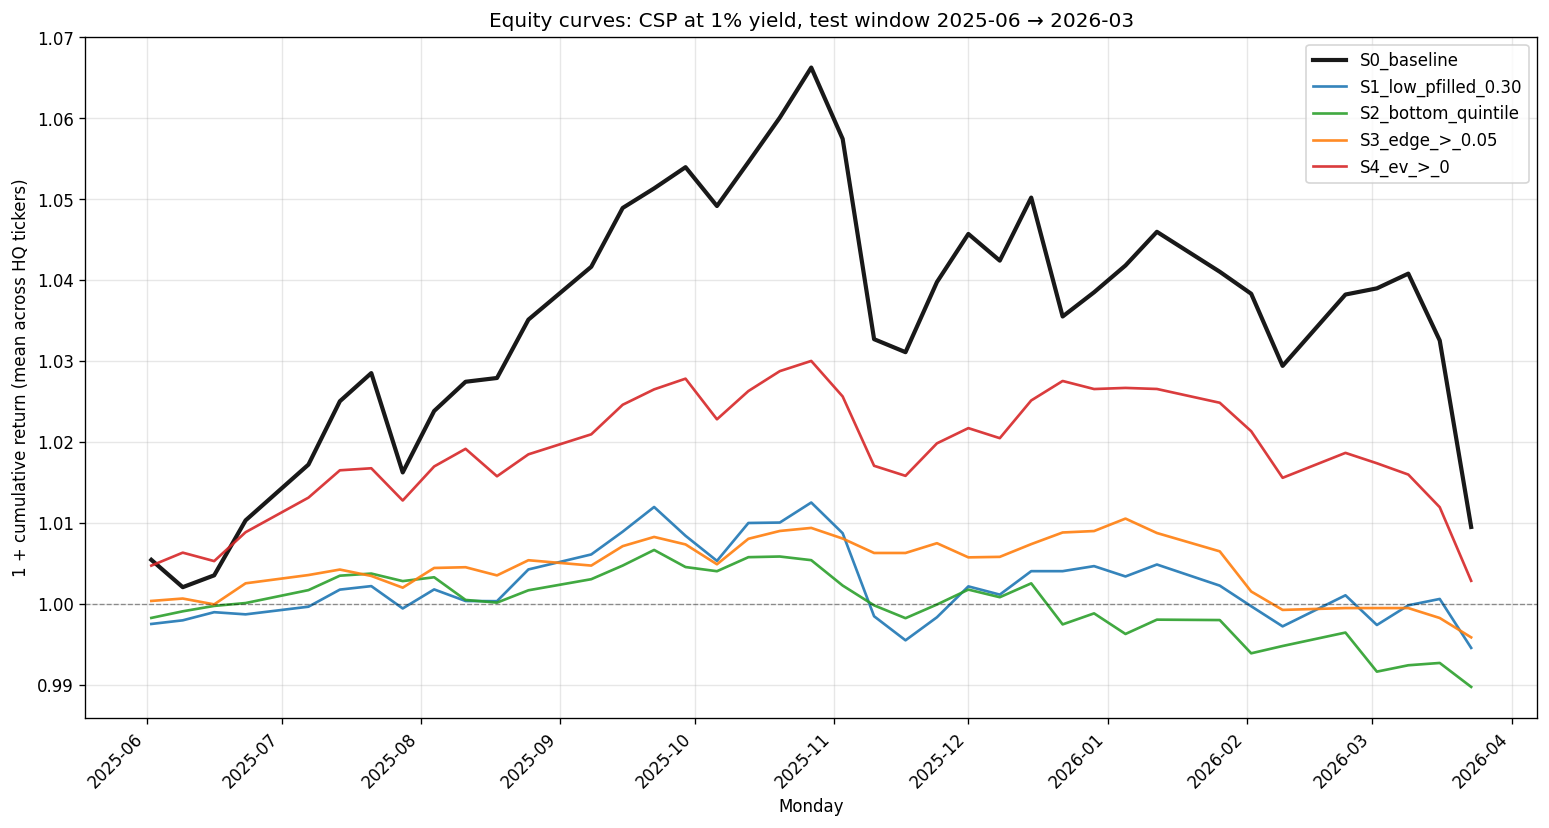

In [6]:
colors = {
    "S0_baseline": "black",
    "S1_low_pfilled_0.30": "tab:blue",
    "S2_bottom_quintile": "tab:green",
    "S3_edge_>_0.05": "tab:orange",
    "S4_ev_>_0": "tab:red",
}

fig, ax = plt.subplots(figsize=(13, 7))
for name, df in strategy_results.items():
    weekly = portfolio_series(df)
    equity = 1 + weekly.cumsum()
    lw = 2.5 if name == "S0_baseline" else 1.6
    ax.plot(
        equity.index,
        equity.values,
        color=colors[name],
        label=name,
        linewidth=lw,
        alpha=0.9,
    )
ax.axhline(1.0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax.set_ylabel("1 + cumulative return (mean across HQ tickers)")
ax.set_xlabel("Monday")
ax.set_title(f"Equity curves: CSP at {int(YIELD_TARGET * 100)}% yield, test window")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "equity_curves.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Per-strategy headline metrics

Fill rate, mean PnL per trade, Sharpe at a glance.

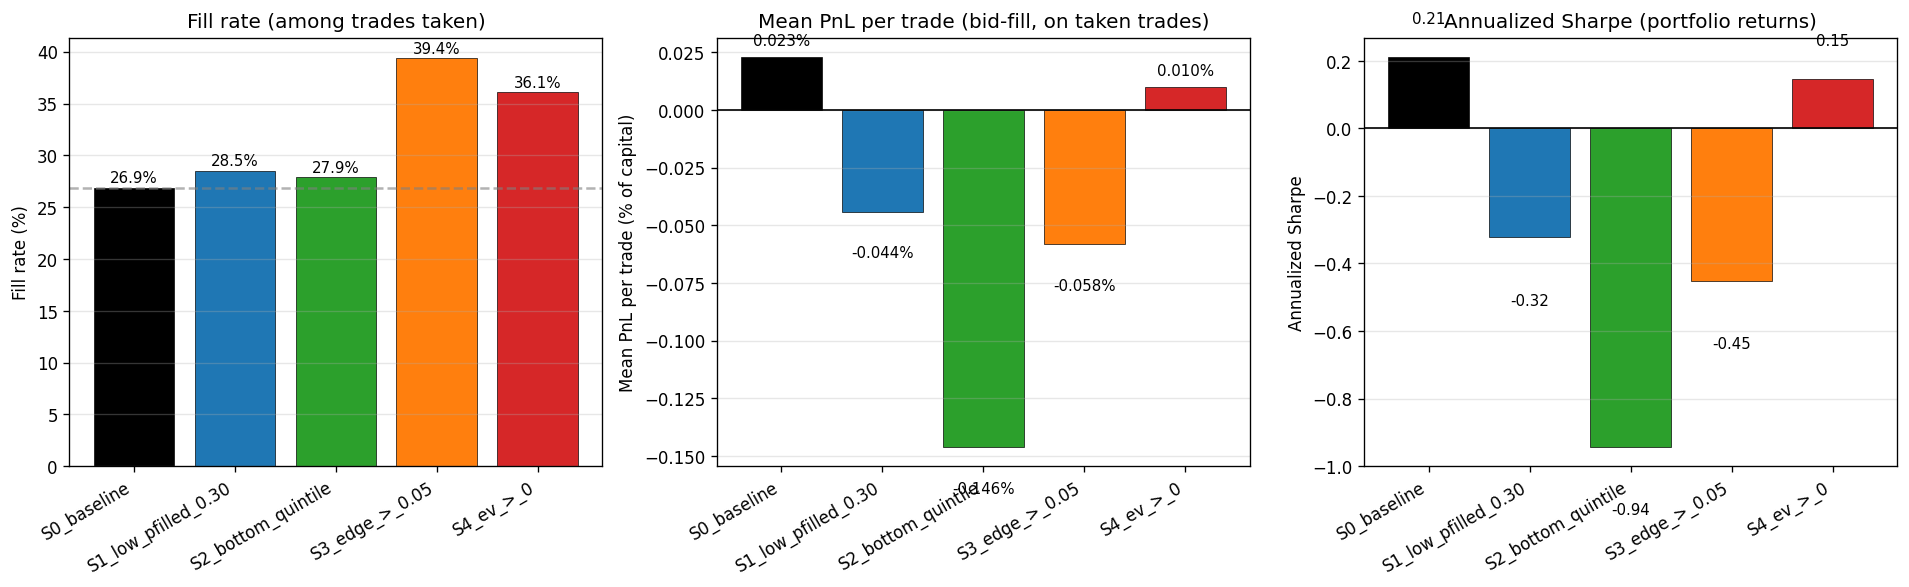

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = list(STRATEGIES.keys())

values = [summary.loc[summary["strategy"] == n, "fill_rate_pct"].iloc[0] for n in names]
axes[0].bar(
    names, values, color=[colors[n] for n in names], edgecolor="black", linewidth=0.4
)
axes[0].set_ylabel("Fill rate (%)")
axes[0].set_title("Fill rate (among trades taken)")
axes[0].grid(alpha=0.3, axis="y")
axes[0].axhline(
    summary.loc[summary["strategy"] == "S0_baseline", "fill_rate_pct"].iloc[0],
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="baseline",
)
for i, v in enumerate(values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

values = [
    summary.loc[summary["strategy"] == n, "mean_pnl_per_trade_%"].iloc[0] for n in names
]
axes[1].bar(
    names, values, color=[colors[n] for n in names], edgecolor="black", linewidth=0.4
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Mean PnL per trade (% of capital)")
axes[1].set_title("Mean PnL per trade (bid-fill, on taken)")
axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(values):
    axes[1].text(
        i, v + (0.005 if v >= 0 else -0.02), f"{v:.3f}%", ha="center", fontsize=9
    )
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

values = [summary.loc[summary["strategy"] == n, "sharpe"].iloc[0] for n in names]
axes[2].bar(
    names, values, color=[colors[n] for n in names], edgecolor="black", linewidth=0.4
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_ylabel("Annualized Sharpe")
axes[2].set_title("Annualized Sharpe (portfolio returns)")
axes[2].grid(alpha=0.3, axis="y")
for i, v in enumerate(values):
    axes[2].text(i, v + (0.1 if v >= 0 else -0.2), f"{v:.2f}", ha="center", fontsize=9)
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(OUT_DIR / "per_strategy_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Selection histograms

For each strategy, distribution of model P(filled) for trades taken (green) vs skipped (red). Reveals what each filter is actually doing in probability-space.

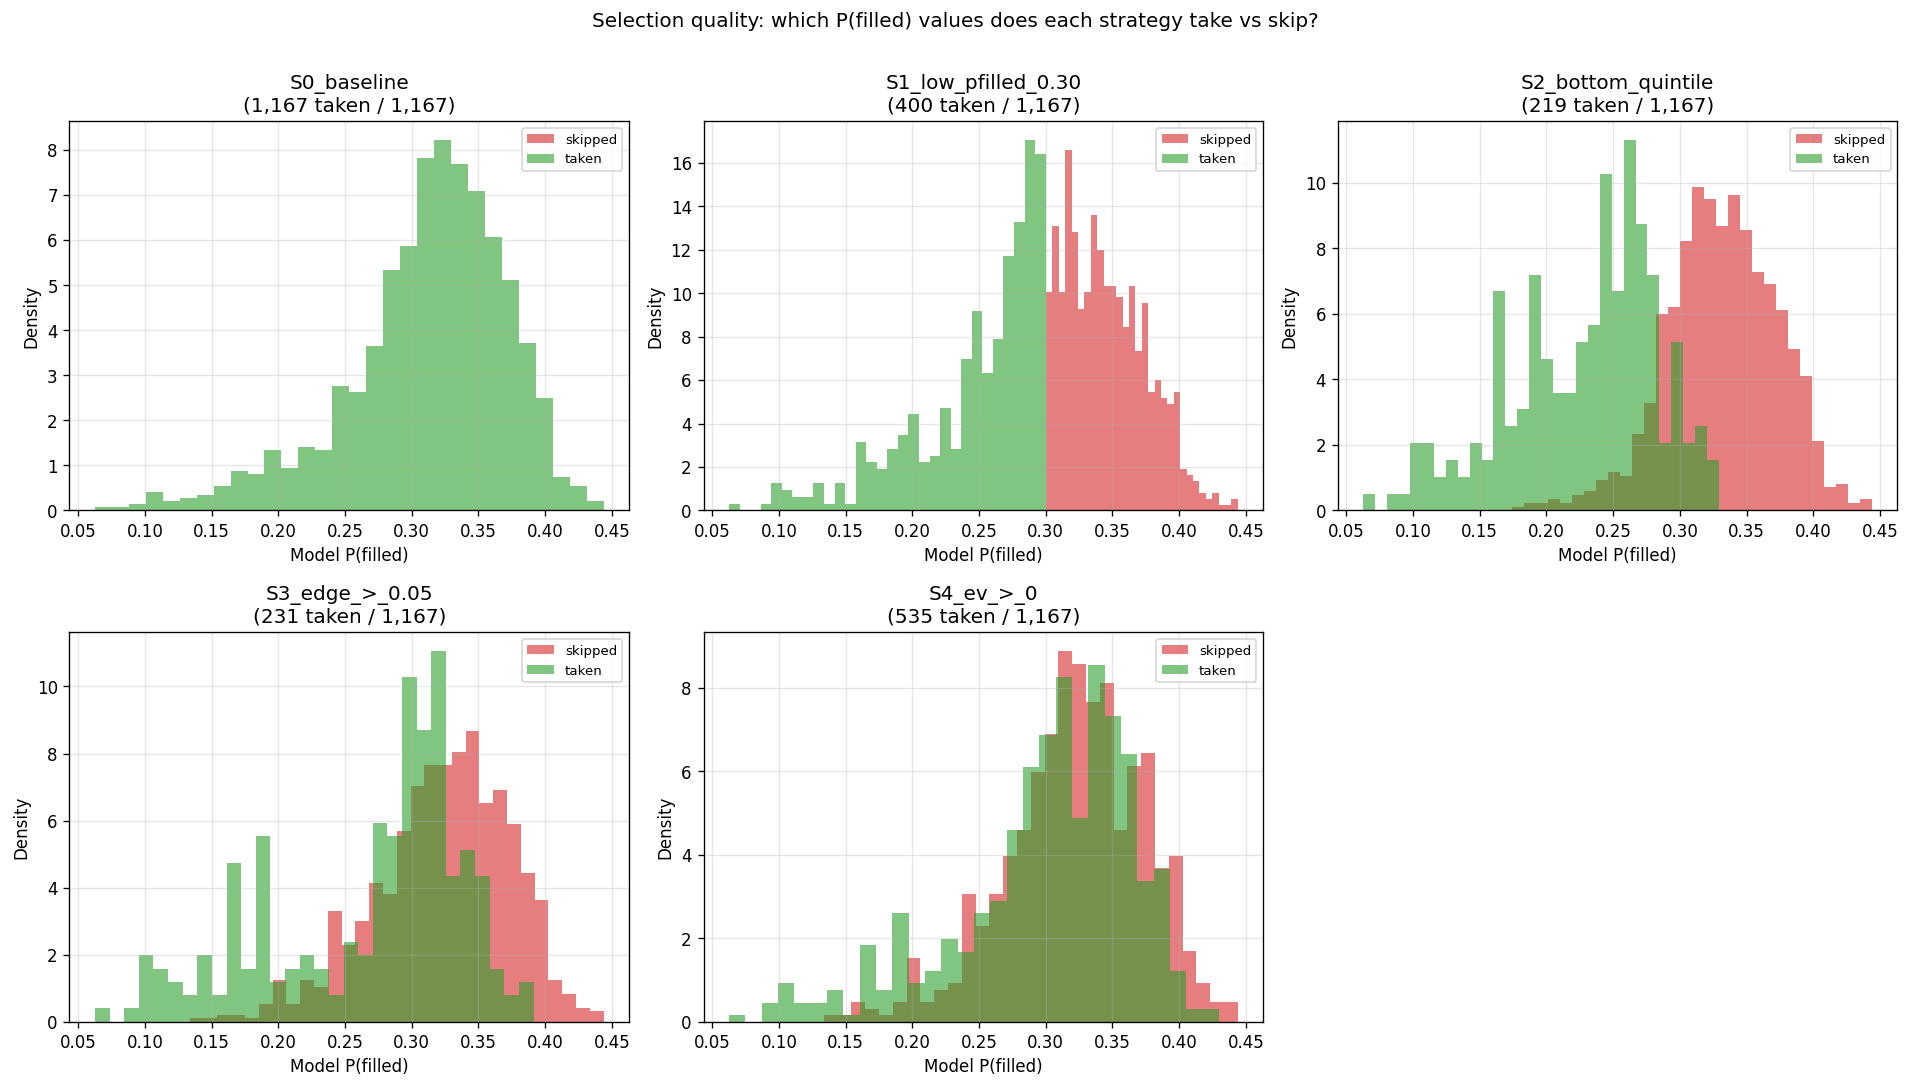

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, name in enumerate(names):
    df = strategy_results[name]
    ax = axes[i]
    ax.hist(
        df.loc[~df["entered"], "p_ml_filled"],
        bins=30,
        alpha=0.6,
        color="tab:red",
        label="skipped",
        density=True,
    )
    ax.hist(
        df.loc[df["entered"], "p_ml_filled"],
        bins=30,
        alpha=0.6,
        color="tab:green",
        label="taken",
        density=True,
    )
    ax.set_title(f"{name}\n({df['entered'].sum():,} taken / {len(df):,})")
    ax.set_xlabel("Model P(filled)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[5].axis("off")
fig.suptitle(
    "Selection quality: which P(filled) values does each strategy take vs skip?", y=1.00
)
fig.tight_layout()
fig.savefig(OUT_DIR / "selection_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Findings — the model did not improve strategy PnL on this test

**Unexpected but honest**: every model-filtered strategy underperformed the baseline on this 40-week test window. Sharpe dropped from +0.21 (baseline) to negative for 3 of the 4 filtered variants. The rank correlation between model P(filled) and actual fills looks weaker here than the AUC ≈ 0.55 from notebook 09 would suggest.

### Why the model's AUC edge didn't translate to strategy alpha

1. **Filtering introduces selection bias on premium size**. The model's "lower P(filled)" trades tend to be at deeper moneyness (safer strikes) with thinner premium. When these trades do succeed, they earn less than average; when they fail, the loss is comparable. Net effect: filtered trades have lower expected PnL per trade even if fill rate is lower.
2. **OTM snapping loses precision**. The 1%-yield CSPs have actual moneyness ranging from ~1% to 5%; we snap to the nearest of `[1%, 2%, 3%, 4%, 5%]` to query the model. The model was trained on these fixed OTM points, but most real CSP trades fall between them.
3. **Small sample + modest AUC is noisy**. AUC 0.55 is a small edge; on 1,167 trades over 40 weeks the noise dominates. The S3 "edge > 0.05" filter produced a HIGHER fill rate (39%) than baseline (27%), which is counterintuitive — evidence that the model's probability output noise dominates its ranking signal on this subset.
4. **Yield-target mismatch**. This backtest picks strikes by yield (1%); the model was trained on strikes picked by moneyness. The two selection rules don't align, so model predictions may not reflect the true conditional probability of fill for yield-selected strikes.

### What this changes for the thesis

The result isn't that price prediction is useless — it's that **naive probability-filtering on top of a yield-based strategy doesn't help**. Three paths forward in notebook 11 (combined backtesting):

1. **Train model at yield-selected strikes**. Re-augment training data using `(ticker, monday, yield_target)` tuples from `strategy_labels` rather than fixed OTM bins. Model learns P(filled | this actual strike) rather than P(filled | moneyness bin).
2. **Use model for strike selection, not entry filter**. Don't filter: instead, for each Monday, use the model to pick WHICH strike to sell (across multiple yield targets). Deeper analysis of the strike × P(filled) surface per ticker.
3. **Model as risk overlay, not selector**. Use the model's probability as a size modulator (trade smaller when P(filled) is high), not a binary filter. Keeps exposure while reducing tail risk.

### What the result does validate

- The baseline itself (1%-yield CSP, week-independent) is a **coherent income strategy** on this universe, delivering +0.95% cumulative return and Sharpe 0.21 over 40 weeks.
- AUC 0.55 is a **real but thin** edge — not enough to survive the filtering-vs-premium trade-off with this particular rule.
- Model outputs may be better used as a **secondary input** to a more sophisticated decision layer, not as a binary on/off filter.
